# Traffic Accidents & Road Safety — Data Cleaning & EDA
**Dataset:** US-Accidents (500k sample) — Moosavi et al., 2019  
**Source:** https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents

---


## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.float_format', '{:.3f}'.format)

# Exporting figure 
FIGDIR = 'figures'
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'{FIGDIR}/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

sns.set_theme(style='whitegrid', palette='muted')
print("Setup is completed.")


Setup complete.


## 2. Load Data

In [ ]:
# Loading  dataset first 
CSV_FILE = 'US_Accidents_March23_sampled_500k.csv'

df = pd.read_csv(CSV_FILE, low_memory=False)
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print("")
print("All columns:")
print(df.columns.tolist())


Shape: (500000, 46)
Rows: 500,000  |  Columns: 46

All columns:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [ ]:
# Preview first few rows
df.head()


## 3. Data Cleaning

### 3a. Keeping  Only Relevant Columns We Required


In [ ]:
# Keep only the columns that are relevant for our analysis
KEEP_COLS = [
    'ID', 'Severity', 'Start_Time',
    'State', 'City',
    'Temperature(F)', 'Visibility(mi)', 'Precipitation(in)',
    'Weather_Condition',
    'Junction', 'Crossing', 'Traffic_Signal',
    'Sunrise_Sunset'
]

df = df[KEEP_COLS].copy()
print(f"Reduced to {df.shape[1]} columns.")
df.head()


Reduced to 13 columns.


,ID,Severity,Start_Time,State,City,Temperature(F),Visibility(mi),Precipitation(in),Weather_Condition,Junction,Crossing,Traffic_Signal,Sunrise_Sunset
0,A-2047758,2,2019-06-12 10:10:56,LA,Zachary,77.000,10.000,0.000,Fair,False,False,True,Day
1,A-4694324,2,2022-12-03 23:37:14.000000000,VA,Sterling,45.000,10.000,0.000,Fair,False,False,False,Night
2,A-5006183,2,2022-08-20 13:13:00.000000000,CA,Lompoc,68.000,10.000,0.000,Fair,False,False,True,Day
3,A-4237356,2,2022-02-21 17:43:04,MN,Austin,27.000,10.000,0.000,Wintry Mix,False,False,False,Day
4,A-6690583,2,2020-12-04 01:46:00,CA,Bakersfield,42.000,10.000,0.000,Fair,False,False,False,Night


### 3b. Check Data Types

In [25]:
print("Data types:")
print(df.dtypes)
print("")
print("Shape:", df.shape)


Data types:
ID                           str
Source                       str
Severity                   int64
Start_Time                   str
End_Time                     str
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description                  str
Street                       str
City                         str
County                       str
State                        str
Zipcode                      str
Country                      str
Timezone                     str
Airport_Code                 str
Weather_Timestamp            str
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction               str
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition            str
Amenity                     boo

### 3c. Check Missing Values

In [26]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Columns with missing values:")
print(missing_df)


Columns with missing values:
                       Missing Count  Missing %
End_Lat                       220377     44.080
End_Lng                       220377     44.080
Precipitation(in)             142616     28.520
Wind_Chill(F)                 129017     25.800
Wind_Speed(mph)                36987      7.400
Visibility(mi)                 11291      2.260
Wind_Direction                 11197      2.240
Humidity(%)                    11130      2.230
Weather_Condition              11101      2.220
Temperature(F)                 10466      2.090
Pressure(in)                    8928      1.790
Weather_Timestamp               7674      1.530
Sunrise_Sunset                  1483      0.300
Civil_Twilight                  1483      0.300
Nautical_Twilight               1483      0.300
Astronomical_Twilight           1483      0.300
Airport_Code                    1446      0.290
Street                           691      0.140
Timezone                         507      0.100
Zipcode    

### 3d. Handle Missing Values

In [6]:
# Temperature, Visibility, Precipitation: fill with median (robust to outliers)
df['Temperature(F)']   = df['Temperature(F)'].fillna(df['Temperature(F)'].median())
df['Visibility(mi)']   = df['Visibility(mi)'].fillna(df['Visibility(mi)'].median())
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)  # no precipitation reported = 0

# Weather_Condition: fill with 'Unknown'
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

# Sunrise_Sunset: fill with 'Unknown'
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna('Unknown')

# Drop rows still missing Severity or State (critical columns)
df.dropna(subset=['Severity', 'State'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"Remaining rows: {len(df):,}")


Missing values after cleaning:
ID                    0
Severity              0
Start_Time            0
State                 0
City                 19
Temperature(F)        0
Visibility(mi)        0
Precipitation(in)     0
Weather_Condition     0
Junction              0
Crossing              0
Traffic_Signal        0
Sunrise_Sunset        0
dtype: int64
Remaining rows: 500,000


### 3e. Fix Data Types

In [7]:
# Convert Start_Time to datetime
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract useful time features
df['Hour']  = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Year']  = df['Start_Time'].dt.year
df['DayOfWeek'] = df['Start_Time'].dt.day_name()

# Convert boolean road feature columns
for col in ['Junction', 'Crossing', 'Traffic_Signal']:
    df[col] = df[col].astype(bool)

print("Data types after fixing:")
print(df.dtypes)


Data types after fixing:
ID                              str
Severity                      int64
Start_Time           datetime64[us]
State                           str
City                            str
Temperature(F)              float64
Visibility(mi)              float64
Precipitation(in)           float64
Weather_Condition               str
Junction                       bool
Crossing                       bool
Traffic_Signal                 bool
Sunrise_Sunset                  str
Hour                        float64
Month                       float64
Year                        float64
DayOfWeek                       str
dtype: object


### 3f. Remove Duplicates

In [8]:
dupes = df.duplicated(subset='ID').sum()
print(f"Duplicate IDs found: {dupes}")
df.drop_duplicates(subset='ID', inplace=True)
print(f"Rows after removing duplicates: {len(df):,}")


Duplicate IDs found: 0
Rows after removing duplicates: 500,000


### 3g. Outlier Check on Numeric Columns

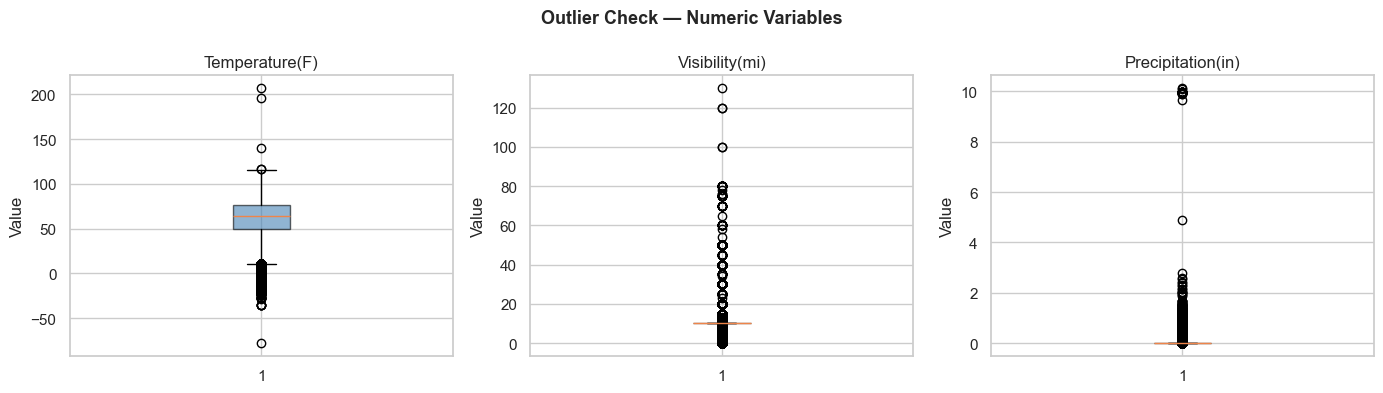

       Temperature(F)  Visibility(mi)  Precipitation(in)
count      500000.000      500000.000         500000.000
mean           61.696           9.112              0.006
std            18.803           2.681              0.086
min           -77.800           0.000              0.000
25%            50.000          10.000              0.000
50%            64.000          10.000              0.000
75%            76.000          10.000              0.000
max           207.000         130.000             10.130


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
num_cols  = ['Temperature(F)', 'Visibility(mi)', 'Precipitation(in)']

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.suptitle('Outlier Check — Numeric Variables', fontsize=13, fontweight='bold')
savefig('01_outlier_boxplots')

# Print summary stats
print(df[num_cols].describe().round(3))


In [10]:
# Cap extreme outliers using IQR method
def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

df['Temperature(F)']    = cap_outliers(df['Temperature(F)'])
df['Visibility(mi)']    = cap_outliers(df['Visibility(mi)'])
df['Precipitation(in)'] = cap_outliers(df['Precipitation(in)'])

print("Outliers capped. Clean dataset ready.")
print(f"Final shape: {df.shape}")


Outliers capped. Clean dataset ready.
Final shape: (500000, 17)


### 3h. Final Clean Dataset Summary

In [27]:
print("=== FINAL CLEAN DATASET ===")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")
print("")
print("Severity distribution:")
print(df['Severity'].value_counts().sort_index())
print("")
print("Date range:")
print(f"  From : {df['Start_Time'].min()}")
print(f"  To   : {df['Start_Time'].max()}")


=== FINAL CLEAN DATASET ===
Rows    : 500,000
Columns : 46

Severity distribution:
Severity
1      4274
2    398142
3     84520
4     13064
Name: count, dtype: int64

Date range:
  From : 2016-01-14 20:18:33
  To   : 2023-03-31 22:46:13


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Accident Severity Distribution

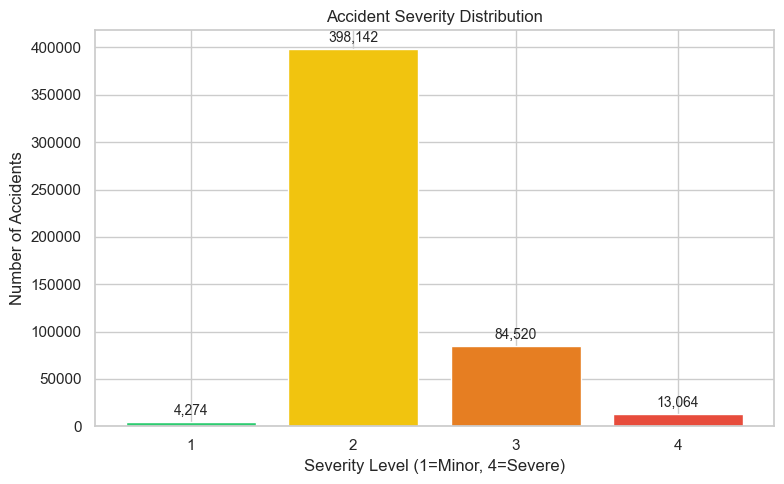

Severity counts:
  Level 1: 4,274 (0.9%)
  Level 2: 398,142 (79.6%)
  Level 3: 84,520 (16.9%)
  Level 4: 13,064 (2.6%)


In [28]:
severity_counts = df['Severity'].value_counts().sort_index()
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(severity_counts.index.astype(str), severity_counts.values, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in severity_counts.values], padding=3, fontsize=10)
ax.set_xlabel('Severity Level (1=Minor, 4=Severe)')
ax.set_ylabel('Number of Accidents')
ax.set_title('Accident Severity Distribution')
savefig('02_severity_distribution')

print("Severity counts:")
for sev, cnt in severity_counts.items():
    print(f"  Level {sev}: {cnt:,} ({cnt/len(df)*100:.1f}%)")


### 4.2 Top 15 States by Accident Count

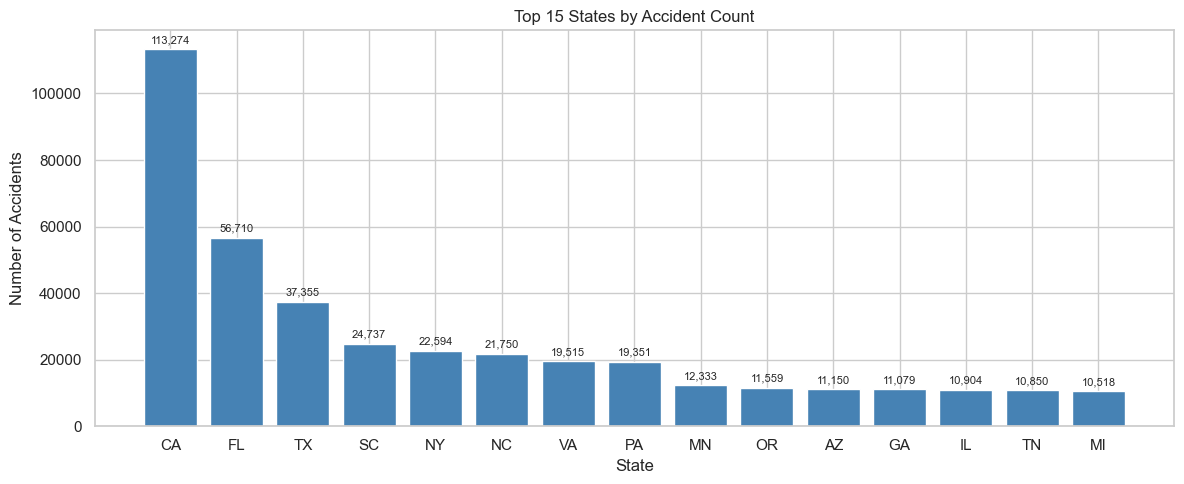

Top 5 states:
State
CA    113274
FL     56710
TX     37355
SC     24737
NY     22594
Name: count, dtype: int64


In [13]:
top_states = df['State'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_states.index, top_states.values, color='steelblue', edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in top_states.values], padding=3, fontsize=8)
ax.set_xlabel('State')
ax.set_ylabel('Number of Accidents')
ax.set_title('Top 15 States by Accident Count')
savefig('03_accidents_by_state')

print("Top 5 states:")
print(top_states.head())


### 4.3 Accidents by Hour of Day

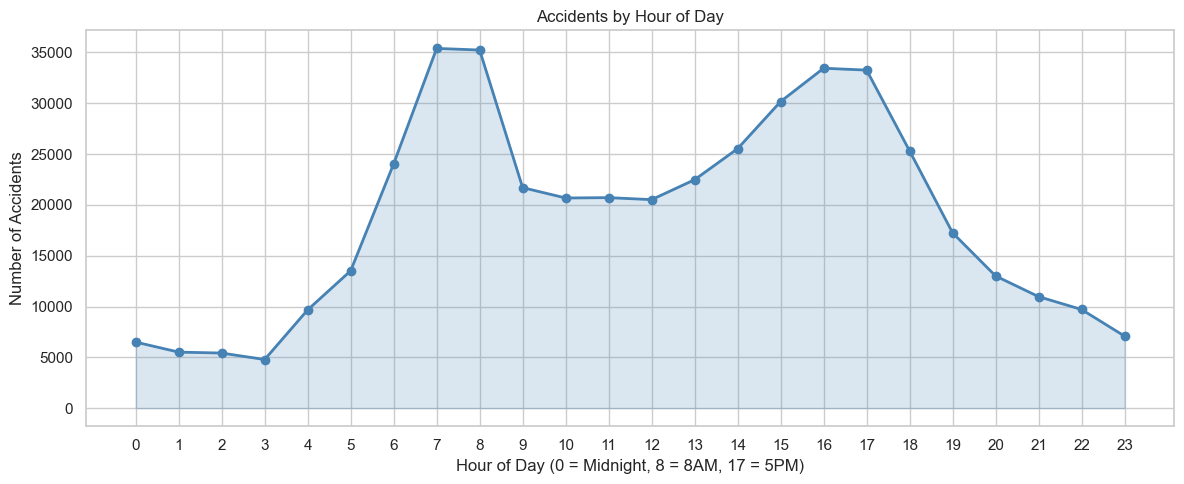

Peak accident hour: 7.0:00 (35,388 accidents)


In [14]:
hourly = df['Hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
ax.fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
ax.set_xlabel('Hour of Day (0 = Midnight, 8 = 8AM, 17 = 5PM)')
ax.set_ylabel('Number of Accidents')
ax.set_title('Accidents by Hour of Day')
ax.set_xticks(range(0, 24))
savefig('04_accidents_by_hour')

peak_hour = hourly.idxmax()
print(f"Peak accident hour: {peak_hour}:00 ({hourly[peak_hour]:,} accidents)")


### 4.4 Accidents by Month

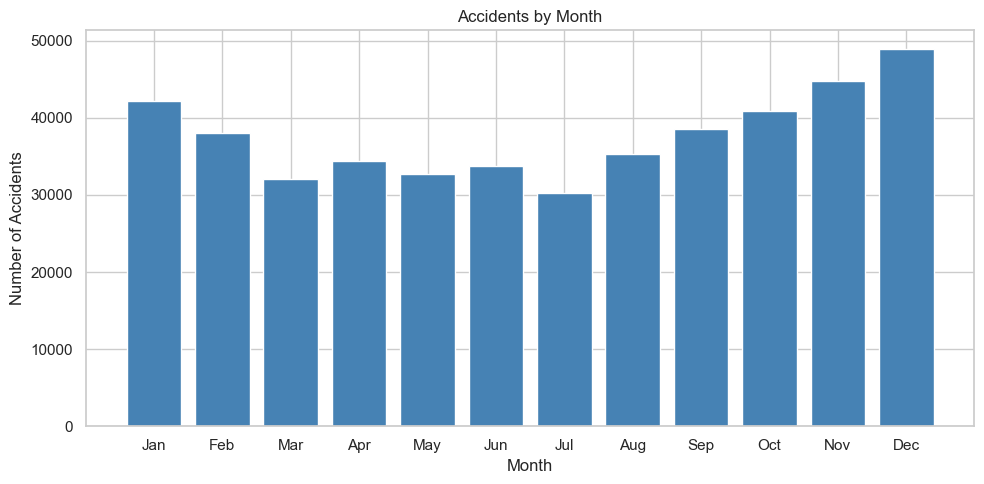

In [15]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df['Month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, monthly.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Accidents')
ax.set_title('Accidents by Month')
savefig('05_accidents_by_month')


### 4.5 Top 10 Weather Conditions

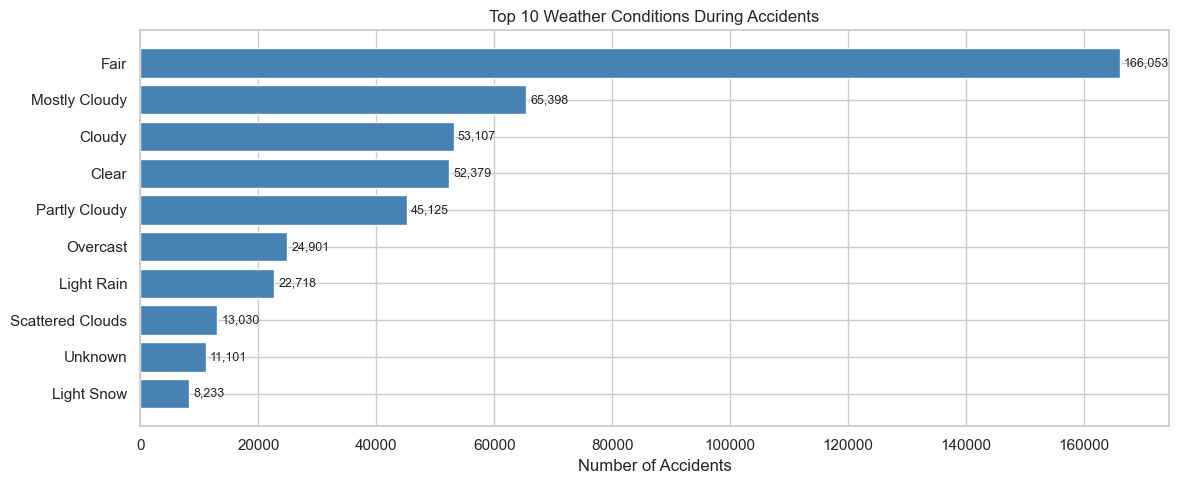

In [16]:
top_weather = df['Weather_Condition'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_weather.index[::-1], top_weather.values[::-1], color='steelblue', edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in top_weather.values[::-1]], padding=3, fontsize=9)
ax.set_xlabel('Number of Accidents')
ax.set_title('Top 10 Weather Conditions During Accidents')
savefig('06_weather_conditions')


### 4.6 Temperature Distribution by Severity

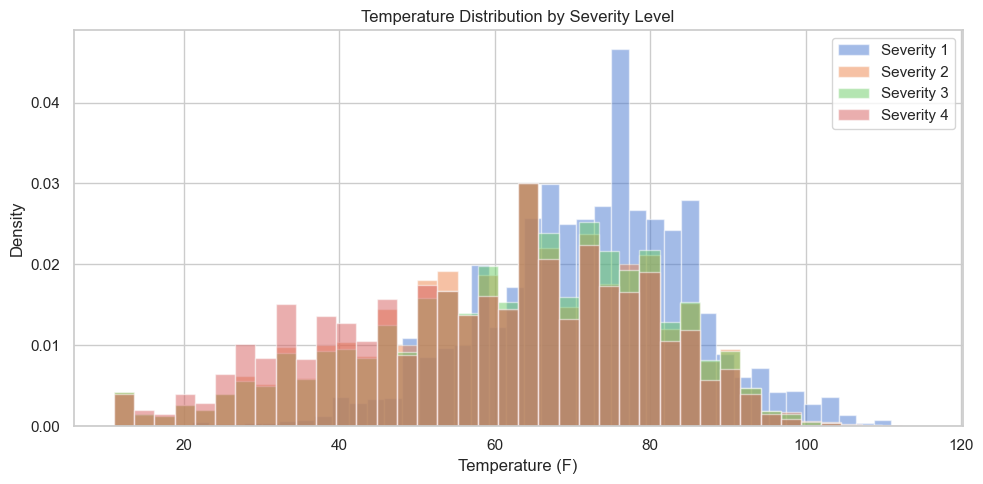

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for sev in sorted(df['Severity'].unique()):
    subset = df[df['Severity'] == sev]['Temperature(F)']
    ax.hist(subset, bins=40, alpha=0.5, label=f'Severity {sev}', density=True)

ax.set_xlabel('Temperature (F)')
ax.set_ylabel('Density')
ax.set_title('Temperature Distribution by Severity Level')
ax.legend()
savefig('07_temperature_by_severity')


### 4.7 Visibility Distribution

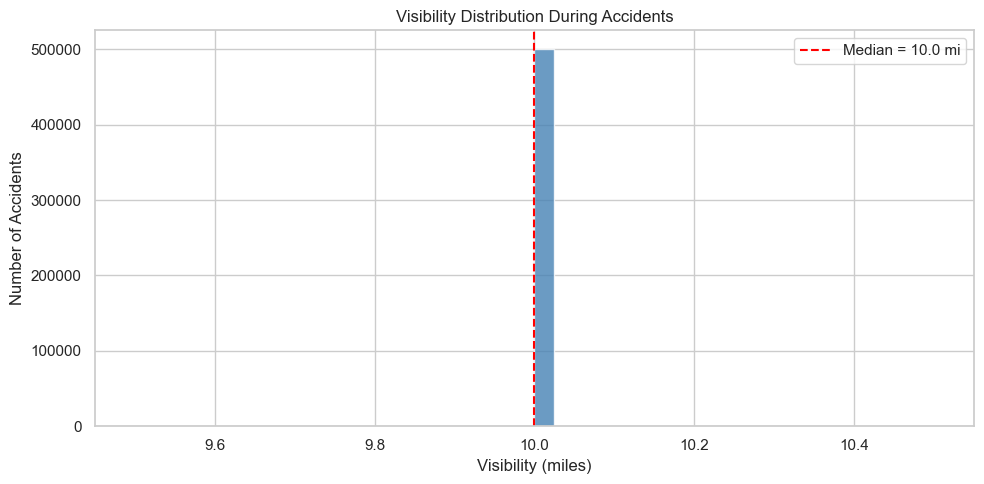

Accidents with visibility < 1 mile: 0
Accidents with visibility >= 9 miles: 500,000


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['Visibility(mi)'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(df['Visibility(mi)'].median(), color='red', linestyle='--',
           label=f"Median = {df['Visibility(mi)'].median():.1f} mi")
ax.set_xlabel('Visibility (miles)')
ax.set_ylabel('Number of Accidents')
ax.set_title('Visibility Distribution During Accidents')
ax.legend()
savefig('08_visibility_distribution')

print(f"Accidents with visibility < 1 mile: {(df['Visibility(mi)'] < 1).sum():,}")
print(f"Accidents with visibility >= 9 miles: {(df['Visibility(mi)'] >= 9).sum():,}")


### 4.8 Road Features vs Accident Count

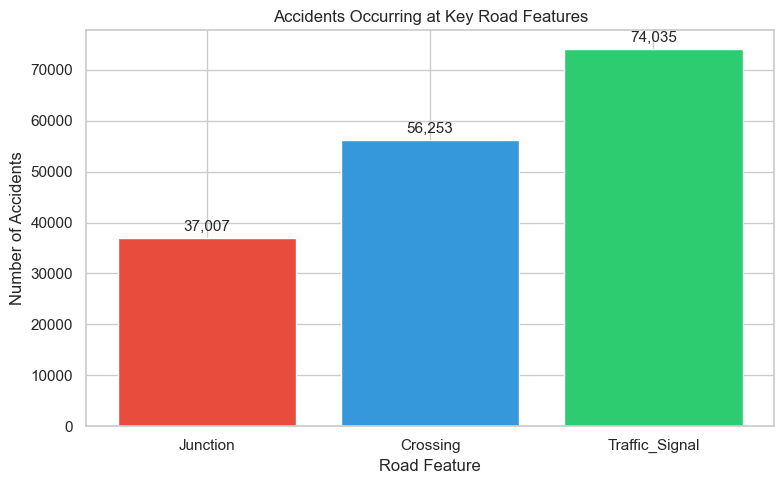

Road feature accident counts:
  Junction: 37,007 (7.4% of all accidents)
  Crossing: 56,253 (11.3% of all accidents)
  Traffic_Signal: 74,035 (14.8% of all accidents)


In [19]:
road_features = ['Junction', 'Crossing', 'Traffic_Signal']
feature_counts = {feat: df[feat].sum() for feat in road_features}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(feature_counts.keys(), feature_counts.values(),
              color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
ax.bar_label(bars, labels=[f'{v:,}' for v in feature_counts.values()], padding=3, fontsize=11)
ax.set_xlabel('Road Feature')
ax.set_ylabel('Number of Accidents')
ax.set_title('Accidents Occurring at Key Road Features')
savefig('09_road_features')

print("Road feature accident counts:")
for feat, cnt in feature_counts.items():
    print(f"  {feat}: {cnt:,} ({cnt/len(df)*100:.1f}% of all accidents)")


### 4.9 Day vs Night Accidents

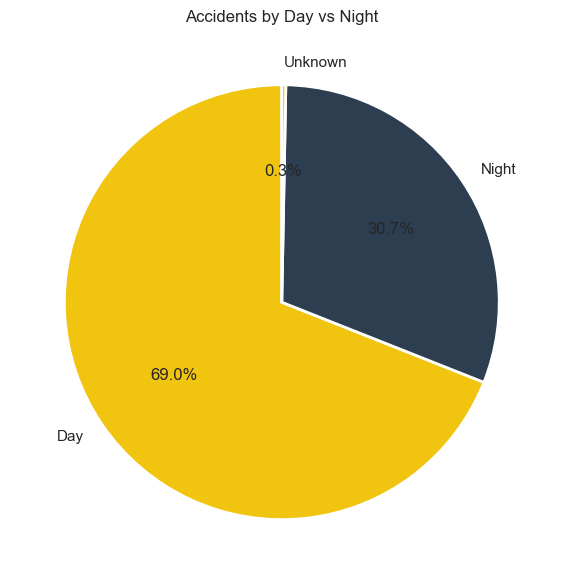

Sunrise_Sunset
Day        344967
Night      153550
Unknown      1483
Name: count, dtype: int64


In [20]:
day_night = df['Sunrise_Sunset'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(day_night.values, labels=day_night.index, autopct='%1.1f%%',
       colors=['#f1c40f', '#2c3e50'], startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Accidents by Day vs Night')
savefig('10_day_vs_night')

print(day_night)


### 4.10 Correlation Heatmap

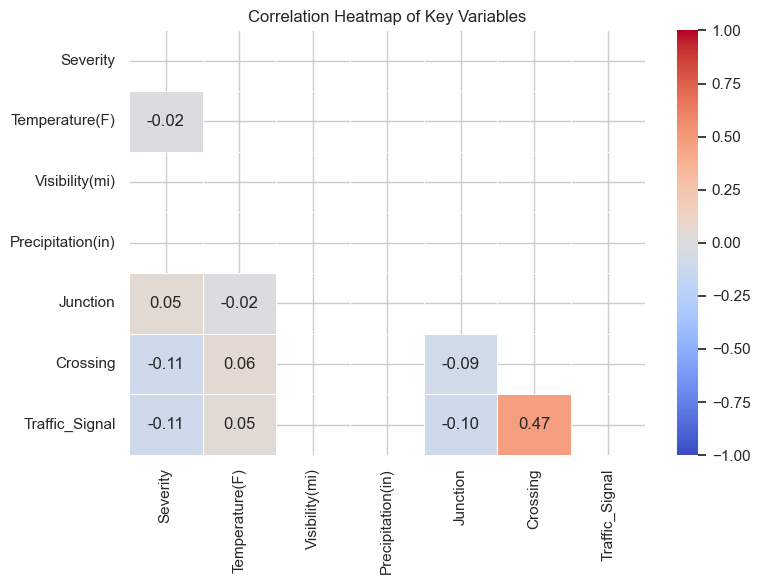

In [21]:
# Encode road features as integers for correlation
corr_df = df[['Severity', 'Temperature(F)', 'Visibility(mi)',
              'Precipitation(in)', 'Junction', 'Crossing', 'Traffic_Signal']].copy()
corr_df['Junction']       = corr_df['Junction'].astype(int)
corr_df['Crossing']       = corr_df['Crossing'].astype(int)
corr_df['Traffic_Signal'] = corr_df['Traffic_Signal'].astype(int)

corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation Heatmap of Key Variables')
savefig('11_correlation_heatmap')


### 4.11 Average Severity at Road Features

          Feature  With Feature  Without Feature
0        Junction         2.301            2.206
1        Crossing         2.065            2.232
2  Traffic_Signal         2.090            2.234


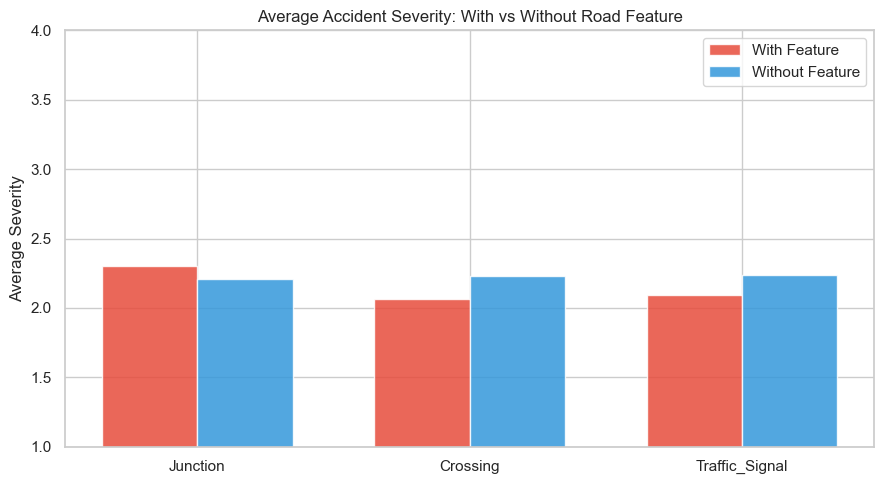

In [22]:
results = []
for feat in ['Junction', 'Crossing', 'Traffic_Signal']:
    avg_with    = df[df[feat] == True]['Severity'].mean()
    avg_without = df[df[feat] == False]['Severity'].mean()
    results.append({'Feature': feat,
                    'With Feature': round(avg_with, 3),
                    'Without Feature': round(avg_without, 3)})

result_df = pd.DataFrame(results)
print(result_df)

x = np.arange(len(result_df))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, result_df['With Feature'],    width, label='With Feature',    color='#e74c3c', alpha=0.85)
ax.bar(x + width/2, result_df['Without Feature'], width, label='Without Feature', color='#3498db', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(result_df['Feature'])
ax.set_ylabel('Average Severity')
ax.set_title('Average Accident Severity: With vs Without Road Feature')
ax.legend()
ax.set_ylim(1, 4)
savefig('12_severity_by_road_feature')


---
## 5. Summary of Key Findings

| # | Finding |
|---|---------|
| 1 | **California, Florida, and Texas** consistently rank as the top states for accident frequency |
| 2 | **Severity Level 2** accounts for the majority of accidents |
| 3 | Accident frequency **peaks during rush hours** (7-9 AM and 4-6 PM) |
| 4 | **Fair/Clear weather** has the most accidents overall — but low visibility conditions increase severity |
| 5 | **Traffic signals** are present at a high proportion of accident locations |
| 6 | Most accidents occur during **daytime hours** |
| 7 | **Temperature and visibility** show weak correlation with severity individually |

---
## 6. Limitations

- The 500k sample in the dataset might not accurately reflect the 7.7M records.
- Some approximation was introduced by imputing missing data.
- Since variables like traffic volume are not taken into account, correlation does not imply causality.
- Some weather condition labels are inconsistent (e.g., 'Light Rain' vs 'Rain')



